In [1]:
# --- bootstrap chemin : racine du projet + pipeline PROD (data/, features_static, product_feats) ---
import os, sys
while not os.path.isdir("data") and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir("..")
for _p in (os.getcwd(), os.path.join(os.getcwd(), "PROD", "pipeline")):
    if _p not in sys.path: sys.path.insert(0, _p)

# Feature engineering : traduire la fraude en variables

L'EDA a **caractérisé** la fraude : un panier frauduleux, c'est **un bien cher et
facile à revendre** (Apple, poussettes premium), **livré**, **sans garantie**,
acheté seul, pas un lot revendu en volume. Le mobile est la **revente rapide**.

Ce notebook **traduit** cette caractérisation en variables. Principe directeur :

> **Aucune feature qui ne corresponde à une hypothèse de fraude.**

On génère **large** (~35 variables), réparties en **7 facettes**, chacune répondant à
une question précise sur le panier. Le notebook suivant mesurera leur importance par
**SHAP**, en les comparant à une **variable aléatoire `rand`** qui sert de *repère de
bruit* : une variable qui ne bat pas le hasard n'apporte rien. Cette mesure servira
à **comprendre** ce sur quoi le modèle s'appuie, pas nécessairement à élaguer.

**Deux conventions**, décidées en amont :
- Les catégorielles `dom_cat` / `dom_make` restent **en texte brut** : leur encodage
  (CatBoostEncoder, sans fuite) se fera dans le notebook modèle, à l'intérieur du split.
- On exclut le bloc synthétique `ABC` (`is_synthetic == 0`), comme dans l'EDA.


## D'où viennent ces variables : le lien avec l'EDA

Chaque facette traduit un **constat chiffré** de l'analyse exploratoire. Le tableau
ci-dessous établit la correspondance, constat par constat : c'est ce qui garantit
qu'aucune variable n'est créée « au cas où ».

| Constat de l'EDA | Chiffre observé | Variables créées |
|---|---|---|
| La fraude vise des produits **chers** | prix du dominant : médiane **1 249 €** (fraude) vs **999 €** (légitime) | `total`, `dom_price`, `val_high`, `nb_biens_chers`, `prix_rond` |
| Certaines **catégories et marques** sont ciblées | téléphonie **×1,84**, informatique **×1,53** ; Silver Cross **×3,67**, Apple **×1,30** ; TV **×0,24** | `dom_cat`, `dom_make`, `is_apple`, `is_pram_premium`, `is_cat_liquide`, `part_liquide` |
| La valeur se **concentre sur un seul produit** | **80,5 %** des paniers ne contiennent qu'un bien | `part_dom`, `part_top2`, `ecart_dom`, `prix_std`, `prix_cv` |
| Ce n'est **pas de la revente en volume** | 3 biens ou plus : lift **0,48** ; article en plusieurs exemplaires : lift **0,53** | `taille`, `is_mono`, `is_duo`, `is_3plus`, `nb_distinct`, `qty_total`, `max_qty`, `n_multi`, `nb_petits` |
| **L'absence de garantie** est le signal le plus net | garantie présente dans **1,6 %** des fraudes vs **8,8 %** des légitimes (lift **0,18**) | `has_warranty`, `nb_garanties`, `ratio_garantie`, `has_accessoires` |
| La marchandise est **livrée**, pas retirée | livraison dans **42 %** des fraudes vs **29 %** des légitimes (lift **1,43**) | `has_delivery`, `nb_services`, `ratio_service` |
| Les produits **sans marque** ne fraudent quasiment pas | générique / sans marque : lift **0,01** | `nb_sans_marque` |
| Le **produit exact** discrimine bien mieux que sa marque | iPad Pro 11 Cellular **~11 %** vs Apple Watch **~0 %**, alors que les deux sont « Apple » | la **famille produit** (10 variables, section finale) |

**Deux variables sont des hypothèses, pas des constats** : `nb_cat_distinctes` et
`nb_make_distinctes` testent l'idée qu'un panier incohérent (plusieurs univers
mélangés) serait suspect. L'EDA n'a **pas** examiné cette question. On les crée pour
les mettre à l'épreuve, en assumant qu'elles puissent ne rien apporter.


## Préparation

On charge les données nettoyées et on extrait, pour chaque panier, les tableaux
bruts des 24 emplacements (catégorie, prix, marque, quantité, code produit) plus
un **masque des vrais biens** (on écarte les lignes *garantie* et *service/livraison*,
qui ne sont pas des produits). Ces tableaux alimenteront les 7 facettes.


In [2]:
import numpy as np, pandas as pd
import warnings; warnings.filterwarnings("ignore")

item_cols  = [f"item{i}"               for i in range(1, 25)]
price_cols = [f"cash_price{i}"         for i in range(1, 25)]
make_cols  = [f"make{i}"               for i in range(1, 25)]
qty_cols   = [f"Nbr_of_prod_purchas{i}" for i in range(1, 25)]
code_cols  = [f"goods_code{i}"         for i in range(1, 25)]

SERVICES = {"FULFILMENT CHARGE", "SERVICE"}    # lignes logistiques (prix ~ 0)
WARRANTY = "WARRANTY"                           # ligne garantie
LIQUID_CATS = {"COMPUTERS", "TELEPHONES FAX MACHINES TWO WAY RADIOS"}  # portables, revente rapide
PRAM_MAKES  = {"SILVER CROSS", "BUGABOO"}       # poussettes premium (revente par la marque)

def prep(path):
    X  = pd.read_csv(path, low_memory=False)
    X  = X[X.is_synthetic == 0].reset_index(drop=True)
    IT = X[item_cols].to_numpy()
    P  = X[price_cols].to_numpy(float)
    MK = X[make_cols].to_numpy()
    Q  = X[qty_cols].to_numpy(float)
    CD = X[code_cols].to_numpy()
    good = pd.notna(IT) & ~np.isin(IT, list(SERVICES)) & (IT != WARRANTY)  # vrais biens
    return dict(ID=X.ID.to_numpy(), IT=IT, P=P, MK=MK, Q=Q, CD=CD, good=good, n=len(X))

A_tr = prep("data/X_train_clean.csv")
A_te = prep("data/X_test_clean.csv")

# catégories d'accessoires (déduites des noms) : câbles, housses, périphériques…
_allcats = pd.Series(A_tr["IT"][A_tr["good"]])
ACC_SET  = {c for c in _allcats.unique() if "ACCESSOR" in c or "CABLE" in c}
print(f"train {A_tr['n']:,} | test {A_te['n']:,}")
print(f"catégories faciles à revendre : {sorted(LIQUID_CATS)}")
print(f"catégories accessoires détectées : {len(ACC_SET)}")

train 92,780 | test 23,196
catégories faciles à revendre : ['COMPUTERS', 'TELEPHONES FAX MACHINES TWO WAY RADIOS']
catégories accessoires détectées : 18


## Les variables en un coup d'œil

Le **dictionnaire complet** des ~35 variables, regroupées par facette. Chaque
section ci-dessous explique *ce que cherche* la facette et calcule ses variables ;
les définitions détaillées sont ici, une fois pour toutes.

| Facette | Variable | Définition |
|---|---|---|
| 💰 **Montant du panier** | `total` | somme des prix des biens du panier |
| | `dom_price` | prix du bien le plus cher (le *dominant*) |
| | `val_high` | somme des biens > 1000 € |
| | `nb_biens_chers` | nombre de biens > 1000 € |
| | `prix_rond` | dominant multiple de 500 € (0/1) |
| 🔄 **Nature du produit** | `dom_cat` | catégorie du bien dominant (texte brut) |
| | `dom_make` | marque du bien dominant (texte brut) |
| | `is_apple` | dominant de marque Apple (0/1) |
| | `is_pram_premium` | dominant Silver Cross / Bugaboo (0/1) |
| | `is_cat_liquide` | dominant en catégorie facile à revendre (0/1) |
| | `part_liquide` | part du montant sur des catégories faciles à revendre |
| 🎯 **Concentration** | `part_dom` | prix du dominant / total |
| | `part_top2` | (2 biens les plus chers) / total |
| | `ecart_dom` | prix du dominant − 2ᵉ prix |
| | `prix_std` | écart-type des prix des biens |
| | `prix_cv` | prix_std / prix moyen (dispersion relative) |
| 📦 **Taille du panier** | `taille` | nombre de biens |
| | `is_mono` / `is_duo` / `is_3plus` | taille = 1 / 2 / ≥3 (0/1) |
| | `nb_distinct` | nombre de produits distincts (SKU) |
| | `qty_total` | somme des quantités achetées |
| | `max_qty` | quantité max sur un seul article |
| | `n_multi` | nombre d'articles pris en 2+ exemplaires |
| | `nb_petits` | nombre de biens < 50 € |
| 🧠 **Garantie / accessoires** | `has_warranty` | au moins une garantie (0/1) |
| | `nb_garanties` | nombre de lignes garantie |
| | `ratio_garantie` | garanties / nombre de biens |
| | `has_accessoires` | au moins un accessoire (câble, housse…) (0/1) |
| 🚚 **Mode de réception** | `has_delivery` | présence d'une ligne livraison/service (0/1) |
| | `nb_services` | nombre de lignes logistiques |
| | `ratio_service` | lignes service / (biens + services) |
| 🧩 **Cohérence** | `nb_cat_distinctes` | nombre de catégories différentes |
| | `nb_make_distinctes` | nombre de marques différentes |
| | `nb_sans_marque` | nombre de biens sans marque (RETAILER / vide) |
| 🎲 **Sentinelle** | `rand` | variable aléatoire uniforme [0,1], repère de bruit |

À ces variables **statiques** s'ajoute une **famille produit** (10 variables), calculée
**in-fold** (elle utilise la cible → voir la section dédiée en fin de notebook) :

| Famille | Variable | Définition |
|---|---|---|
| 🛒 **Propension produit** | `sku_fraude_max` / `sku_fraude_mean` | taux de fraude du SKU le + risqué / moyen du panier |
| | `model_fraude_max` / `model_fraude_mean` | idem au niveau **modèle** exact |
| | `cat_fraude_max` / `cat_fraude_mean` | idem **catégorie** |
| | `make_fraude_max` / `make_fraude_mean` | idem **marque** |
| | `dom_model_fraude` | taux de fraude du **modèle du dominant** |
| | `nb_articles_risque` | nb d'articles à taux > 2× la base |


On calcule les variables **facette par facette** : chaque bloc définit une petite
fonction pure `facette_x(A)` qui renvoie ses colonnes. Un dernier bloc les assemble
en une table `1 panier = 1 ligne`.


In [3]:
FACETTES = []   # liste des fonctions de facette, remplie au fil des blocs

def r_(num, den):
    "ratio robuste : 0 quand le dénominateur est nul (panier sans bien)."
    den = np.asarray(den, float)
    return np.where(den > 0, np.asarray(num, float) / np.where(den > 0, den, 1), 0.0)

def nunique_rows(V, mask):
    "nb de valeurs distinctes par ligne, sur les positions retenues par mask."
    return np.array([len(set(V[i][mask[i]])) for i in range(len(V))])

## Facette 1 : le montant du panier 💰

**Question : les paniers frauduleux portent-ils sur des montants plus élevés ?**

La fraude vise l'acquisition de biens de valeur. Cette facette mesure **combien
d'argent est en jeu** : le montant total, le prix du bien le plus cher, et le poids
des biens à plus de 1000 €.


In [4]:
def facette_enjeu(A):
    P, good = A["P"], A["good"]
    Pg   = np.where(good, P, 0.0)                       # prix des biens, 0 ailleurs
    total = Pg.sum(1)
    Pm   = np.where(good, P, -np.inf); dom = Pm.argmax(1); r = np.arange(A["n"])
    ok   = np.isfinite(Pm[r, dom])
    dom_price = np.where(ok, P[r, dom], 0.0)
    return {
        "total":          total,
        "dom_price":      dom_price,
        "val_high":       np.where(good & (P > 1000), P, 0.0).sum(1),
        "nb_biens_chers": ((good) & (P > 1000)).sum(1),
        "prix_rond":      ((dom_price > 0) & (dom_price % 500 == 0)).astype(int),
    }
FACETTES.append(facette_enjeu)
pd.DataFrame(facette_enjeu(A_tr)).describe().round(1)

,total,dom_price,val_high,nb_biens_chers,prix_rond
count,92780.0,92780.0,92780.0,92780.0,92780.0
mean,1224.6,1140.4,792.8,0.5,0.0
std,767.8,693.4,983.7,0.5,0.1
min,219.0,79.0,0.0,0.0,0.0
25%,774.0,719.0,0.0,0.0,0.0
50%,1099.0,999.0,0.0,0.0,0.0
75%,1499.0,1379.0,1379.0,1.0,0.0
max,21995.0,21995.0,21995.0,5.0,1.0


## Facette 2 : la nature du produit dominant 🔄

**Question : le produit visé appartient-il à une catégorie ou une marque facile à revendre ?**

Certains produits se revendent plus facilement que d'autres (informatique et
téléphonie plus qu'un meuble ; marques recherchées comme Apple). Cette facette
identifie **quoi** est acheté (la catégorie et la marque du bien principal) et
mesure la part du panier en produits facilement revendables.


In [5]:
def facette_liquidite(A):
    P, MK, IT, good = A["P"], A["MK"], A["IT"], A["good"]
    Pm  = np.where(good, P, -np.inf); dom = Pm.argmax(1); r = np.arange(A["n"])
    ok  = np.isfinite(Pm[r, dom])
    dom_cat  = np.where(ok, IT[r, dom], "NONE")
    dom_make = np.where(ok, MK[r, dom], "NONE")
    liq_mask = good & np.isin(IT, list(LIQUID_CATS))
    total    = np.where(good, P, 0.0).sum(1)
    return {
        "dom_cat":         dom_cat,
        "dom_make":        dom_make,
        "is_apple":        (dom_make == "APPLE").astype(int),
        "is_pram_premium": np.isin(dom_make, list(PRAM_MAKES)).astype(int),
        "is_cat_liquide":  np.isin(dom_cat, list(LIQUID_CATS)).astype(int),
        "part_liquide":    r_(np.where(liq_mask, P, 0.0).sum(1), total),
    }
FACETTES.append(facette_liquidite)
f = pd.DataFrame(facette_liquidite(A_tr))
print(f[["is_apple","is_pram_premium","is_cat_liquide"]].mean().round(3).to_string())
f[["dom_cat","dom_make"]].describe()

is_apple           0.693
is_pram_premium    0.003
is_cat_liquide     0.583


,dom_cat,dom_make
count,92780,92095
unique,52,185
top,COMPUTERS,APPLE
freq,49587,64340


## Facette 3 : la concentration de la valeur 🎯

**Question : la valeur du panier est-elle concentrée sur un seul produit ?**

Un panier frauduleux contient typiquement un produit cher qui représente
l'essentiel du montant, plutôt que plusieurs achats de valeur répartie. Cette
facette mesure à quel point **le produit principal écrase le reste** du panier.


In [6]:
def facette_concentration(A):
    P, good = A["P"], A["good"]
    Pg    = np.where(good, P, 0.0)
    total = Pg.sum(1); taille = good.sum(1)
    Psort = -np.sort(-Pg, axis=1)                       # prix décroissants
    top1, top2 = Psort[:, 0], Psort[:, 1]
    Pn    = np.where(good, P, np.nan)
    prix_std = np.nan_to_num(np.nanstd(Pn, axis=1))     # 0 si un seul bien
    prix_moy = r_(total, taille)
    return {
        "part_dom":   r_(top1, total),
        "part_top2":  r_(top1 + top2, total),
        "ecart_dom":  top1 - top2,
        "prix_std":   prix_std,
        "prix_cv":    r_(prix_std, prix_moy),
    }
FACETTES.append(facette_concentration)
pd.DataFrame(facette_concentration(A_tr)).describe().round(2)

,part_dom,part_top2,ecart_dom,prix_std,prix_cv
count,92780.00,92780.00,92780.00,92780.00,92780.00
mean,0.95,0.99,1077.70,77.51,0.14
std,0.13,0.06,707.15,201.15,0.33
min,0.10,0.20,0.00,0.00,0.00
25%,1.00,1.00,619.00,0.00,0.00
50%,1.00,1.00,949.00,0.00,0.00
75%,1.00,1.00,1300.00,0.00,0.00
max,1.00,1.00,21995.00,4212.00,3.39


## Facette 4 : la taille et la composition du panier 📦

**Question : combien de produits le panier contient-il, et de quelle nature ?**

L'EDA montre que la fraude concerne surtout des paniers d'un ou deux produits, et
non des paniers volumineux (les paniers de 3 produits ou plus fraudent moins).
Cette facette décrit **la forme du panier** : sa taille, ses quantités, la présence
de petits achats d'accompagnement.


In [7]:
def facette_structure(A):
    P, Q, CD, good = A["P"], A["Q"], A["CD"], A["good"]
    taille = good.sum(1)
    Qg = np.where(good, np.nan_to_num(Q), 0.0)
    return {
        "taille":      taille,
        "is_mono":     (taille == 1).astype(int),
        "is_duo":      (taille == 2).astype(int),
        "is_3plus":    (taille >= 3).astype(int),
        "nb_distinct": nunique_rows(CD, good),
        "qty_total":   Qg.sum(1),
        "max_qty":     Qg.max(1),
        "n_multi":     (Qg > 1).sum(1),
        "nb_petits":   (good & (P < 50)).sum(1),
    }
FACETTES.append(facette_structure)
pd.DataFrame(facette_structure(A_tr)).describe().round(2)

,taille,is_mono,is_duo,is_3plus,nb_distinct,qty_total,max_qty,n_multi,nb_petits
count,92780.00,92780.00,92780.00,92780.00,92780.00,92780.00,92780.00,92780.00,92780.00
mean,1.37,0.81,0.13,0.07,1.37,1.46,1.06,0.06,0.10
std,1.25,0.40,0.33,0.25,1.25,1.89,0.49,0.39,0.68
min,1.00,0.00,0.00,0.00,1.00,1.00,1.00,0.00,0.00
25%,1.00,1.00,0.00,0.00,1.00,1.00,1.00,0.00,0.00
50%,1.00,1.00,0.00,0.00,1.00,1.00,1.00,0.00,0.00
75%,1.00,1.00,0.00,0.00,1.00,1.00,1.00,0.00,0.00
max,24.00,1.00,1.00,1.00,24.00,98.00,40.00,17.00,22.00


## Facette 5 : la présence de garantie et d'accessoires 🧠

**Question : le panier comporte-t-il une garantie et des accessoires, comme un achat classique ?**

Un acheteur légitime ajoute souvent une garantie ou des accessoires à un produit de
valeur. Leur **absence** est un signal fort : la garantie est présente dans 1,6 %
des paniers frauduleux, contre 8,8 % des légitimes. Cette facette mesure la
couverture du panier (garantie) et la présence d'accessoires.


In [8]:
def facette_rationalite(A):
    IT, good = A["IT"], A["good"]
    taille   = good.sum(1)
    nb_warr  = (IT == WARRANTY).sum(1)
    acc_mask = good & np.isin(IT, list(ACC_SET))
    return {
        "has_warranty":    (nb_warr > 0).astype(int),
        "nb_garanties":    nb_warr,
        "ratio_garantie":  r_(nb_warr, taille),
        "has_accessoires": (acc_mask.sum(1) > 0).astype(int),
    }
FACETTES.append(facette_rationalite)
pd.DataFrame(facette_rationalite(A_tr)).mean().round(3)

has_warranty       0.087
nb_garanties       0.089
ratio_garantie     0.079
has_accessoires    0.238
dtype: float64

## Facette 6 : le mode de réception 🚚

**Question : la commande inclut-elle une livraison plutôt qu'un retrait en magasin ?**

La fraude est plus fréquente lorsque la marchandise est expédiée : une ligne de
frais de livraison est présente dans 42 % des paniers frauduleux, contre 29 % des
légitimes. Cette facette mesure la présence et le poids des **lignes logistiques**.


In [9]:
def facette_logistique(A):
    IT, good = A["IT"], A["good"]
    nb_serv = np.isin(IT, list(SERVICES)).sum(1)
    taille  = good.sum(1)
    return {
        "has_delivery":  (nb_serv > 0).astype(int),
        "nb_services":   nb_serv,
        "ratio_service": r_(nb_serv, taille + nb_serv),
    }
FACETTES.append(facette_logistique)
pd.DataFrame(facette_logistique(A_tr)).mean().round(3)

has_delivery     0.296
nb_services      0.306
ratio_service    0.137
dtype: float64

## Facette 7 : la cohérence du panier 🧩

**Question : le panier est-il cohérent, avec un seul univers de produits et des marques identifiées ?**

Un panier légitime a souvent un thème (équiper une chambre, un bureau). Un mélange
de catégories sans lien, ou des produits sans marque identifiable, peut signaler
une anomalie. Cette facette compte la **diversité** du panier (catégories, marques)
et les produits mal identifiés.


In [10]:
def facette_coherence(A):
    IT, MK, good = A["IT"], A["MK"], A["good"]
    no_brand = good & (pd.isna(MK) | (MK == "RETAILER"))
    return {
        "nb_cat_distinctes":  nunique_rows(IT, good),
        "nb_make_distinctes": nunique_rows(np.where(pd.isna(MK), "NONE", MK), good),
        "nb_sans_marque":     no_brand.sum(1),
    }
FACETTES.append(facette_coherence)
pd.DataFrame(facette_coherence(A_tr)).describe().round(2)

,nb_cat_distinctes,nb_make_distinctes,nb_sans_marque
count,92780.00,92780.00,92780.00
mean,1.21,1.09,0.18
std,0.64,0.54,0.76
min,1.00,1.00,0.00
25%,1.00,1.00,0.00
50%,1.00,1.00,0.00
75%,1.00,1.00,0.00
max,16.00,18.00,20.00


## Assemblage + sentinelle 🎲

On assemble les 7 facettes en une table `1 panier = 1 ligne`, on ajoute la
variable aléatoire **`rand`** (le seuil de bruit pour la sélection à venir), et on
attache le label `fraud` côté train.


In [11]:
def build_features(A, seed=0):
    out = {"ID": A["ID"]}
    for f in FACETTES:
        out.update(f(A))
    out["rand"] = np.random.RandomState(seed).rand(A["n"])   # 🎲 sentinelle
    return pd.DataFrame(out)

F_tr = build_features(A_tr)
F_te = build_features(A_te)

Y = pd.read_csv("data/Y_train.csv")[["ID", "fraud_flag"]].rename(columns={"fraud_flag": "fraud"})
F_tr = F_tr.merge(Y, on="ID"); F_tr["fraud"] = F_tr.fraud.astype(int)

print(f"train {F_tr.shape} | test {F_te.shape}")
print(f"features : {F_tr.shape[1] - 2} (hors ID et fraud)")
F_tr.head(3)

train (92780, 38) | test (23196, 37)
features : 36 (hors ID et fraud)


,ID,total,dom_price,val_high,nb_biens_chers,prix_rond,dom_cat,dom_make,is_apple,is_pram_premium,...,ratio_garantie,has_accessoires,has_delivery,nb_services,ratio_service,nb_cat_distinctes,nb_make_distinctes,nb_sans_marque,rand,fraud
0,85517,889.0,889.0,0.0,0,0,COMPUTERS,APPLE,1,0,...,0.0,0,0,0,0.0,1,1,0,0.548814,0
1,51113,409.0,409.0,0.0,0,0,COMPUTER PERIPHERALS ACCESSORIES,APPLE,1,0,...,0.0,1,0,0,0.0,1,1,0,0.715189,0
2,83008,1399.0,1399.0,1399.0,1,0,TELEVISIONS HOME CINEMA,SAMSUNG,0,0,...,0.0,0,0,0,0.0,1,1,0,0.602763,0


## Contrôle : chaque variable porte-t-elle du signal ?

Avant d'exporter, un coup d'œil rapide : pour chaque variable numérique, on regarde
le **rapport** entre sa moyenne côté fraude et côté légitime (un ratio loin de 1 =
la variable *sépare* les deux populations). C'est un simple contrôle de cohérence.
L'analyse d'importance viendra au notebook suivant, par SHAP face à la sentinelle
`rand`, qui doit justement ressortir **proche de 1** ici.


In [12]:
num = F_tr.select_dtypes("number").drop(columns=["fraud", "ID"])
g = F_tr.groupby("fraud")
ratio = (g[num.columns].mean().loc[1] / g[num.columns].mean().loc[0].replace(0, np.nan))
tab = ratio.rename("fraude/légit").to_frame()
tab["|écart à 1|"] = (tab["fraude/légit"] - 1).abs()
tab.sort_values("|écart à 1|", ascending=False).round(2)

,fraude/légit,|écart à 1|
is_pram_premium,2.39,1.39
nb_garanties,0.18,0.82
has_warranty,0.18,0.82
ratio_garantie,0.19,0.81
nb_sans_marque,0.26,0.74
prix_rond,0.28,0.72
part_liquide,1.58,0.58
is_cat_liquide,1.57,0.57
val_high,1.57,0.57
is_3plus,0.47,0.53


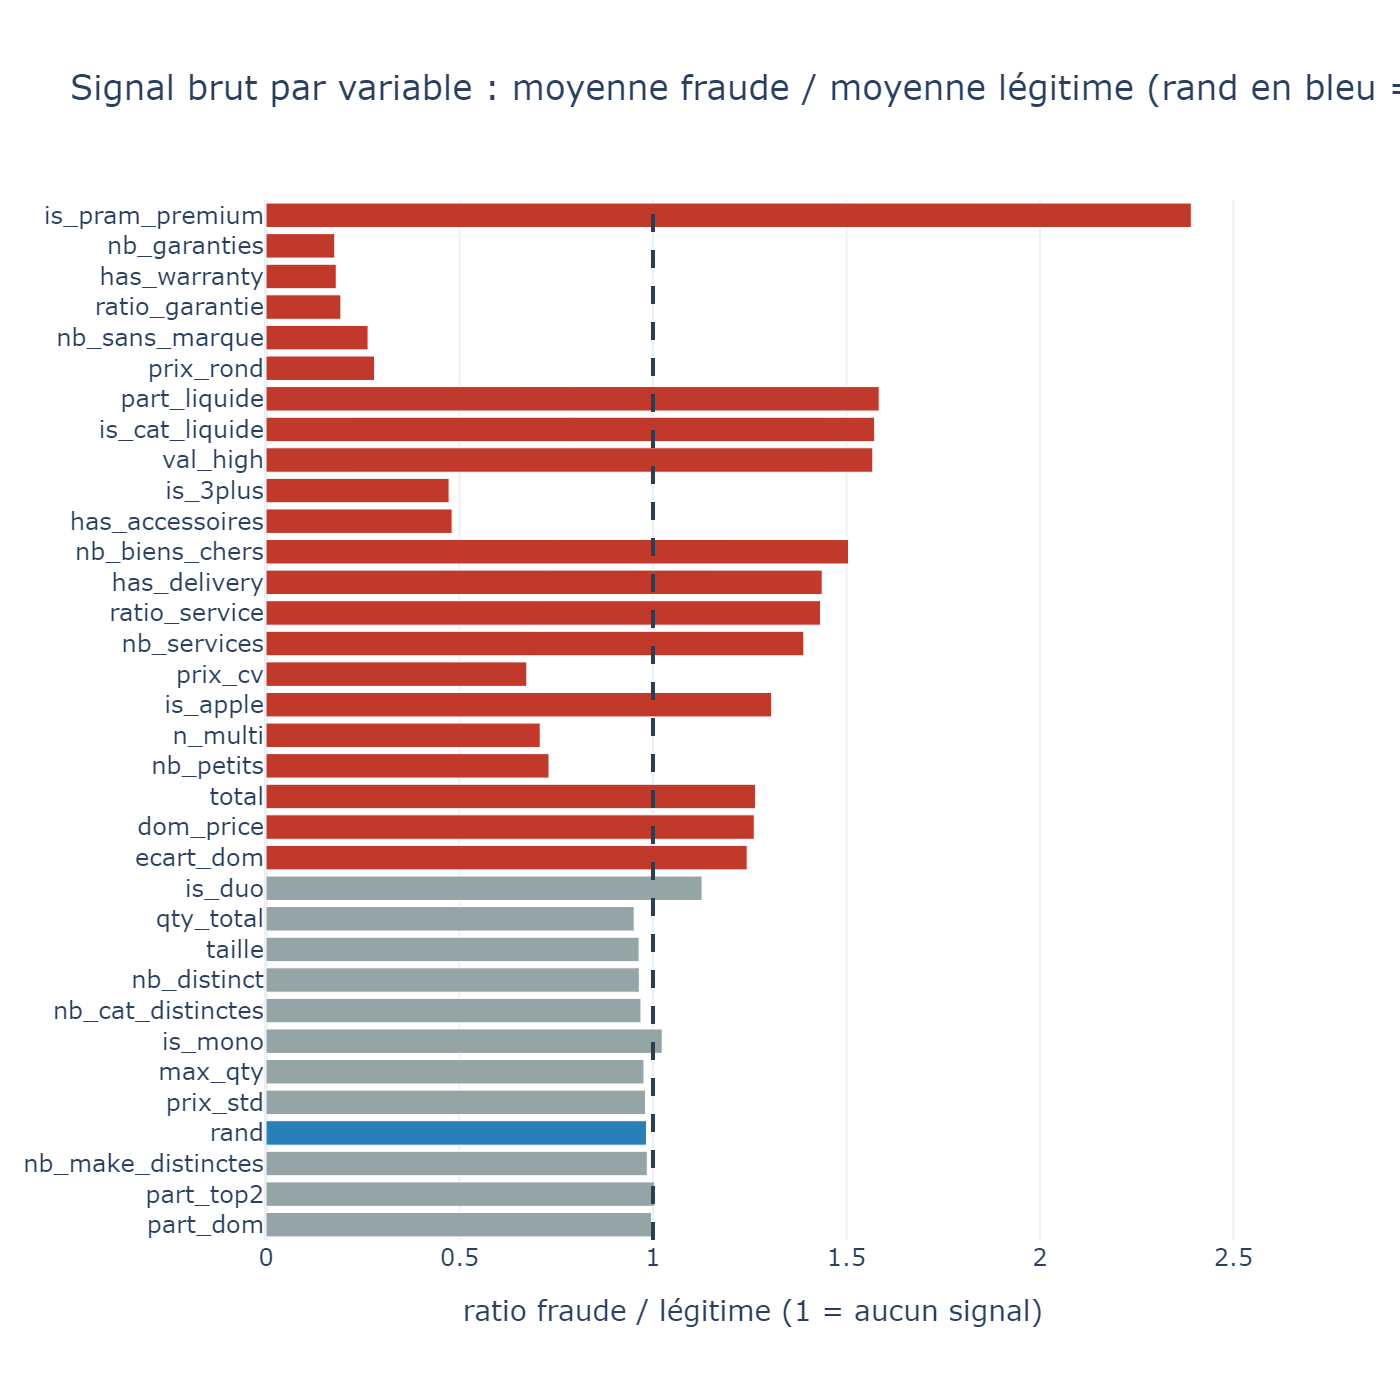

In [13]:
import plotly.graph_objects as go
import os
from IPython.display import Image
os.makedirs("DEV/images", exist_ok=True)
s = tab.sort_values("|écart à 1|").dropna()
col = ["#c0392b" if abs(v-1) > 0.15 else "#95a5a6" for v in s["fraude/légit"]]
col[list(s.index).index("rand")] = "#2980b9" if "rand" in s.index else col[0]  # sentinelle en bleu
fig = go.Figure(go.Bar(x=s["fraude/légit"], y=s.index, orientation="h", marker_color=col))
fig.add_vline(x=1, line_dash="dash", line_color="#2c3e50")
fig.update_layout(template="plotly_white", height=700,
    title="Signal brut par variable : moyenne fraude / moyenne légitime (rand en bleu = repère)",
    xaxis_title="ratio fraude / légitime (1 = aucun signal)")
fig.write_image("DEV/images/fe_signal_par_variable.png", scale=2)
display(Image(filename="DEV/images/fe_signal_par_variable.png"))

## Export

On sauvegarde les **variables statiques** (train avec label, test sans) dans `data/`.
Elles alimenteront le notebook **sélection** puis le notebook **modèle**, où
`dom_cat` / `dom_make` seront encodées sans fuite.

La section suivante présente une **dernière famille de variables**, absente de cet
export : elle utilise la cible, donc la stocker en dur créerait une fuite.


In [14]:
F_tr.to_csv("data/features_train.csv", index=False)
F_te.to_csv("data/features_test.csv",  index=False)
print("écrit : data/features_train.csv", F_tr.shape)
print("écrit : data/features_test.csv ", F_te.shape)

écrit : data/features_train.csv (92780, 38)
écrit : data/features_test.csv  (23196, 37)


## La propension-fraude produit (calculée in-fold)

Les 7 facettes décrivent le panier, mais elles ne voient le produit qu'à travers sa
**catégorie** et sa **marque**. Or `dom_make = APPLE` mélange des risques très
différents : un **iPad Pro 11 Cellular** fraude à **~11 %**, une **Apple Watch** à
**~0 %**. Le signal est dans le **produit exact**.

On crée donc une famille de variables de **propension-fraude produit** : pour chaque
granularité (**SKU** `goods_code`, **modèle**, **catégorie**, **marque**), un **taux
de fraude par valeur** appris sur le train, puis **agrégé sur le panier** (max /
moyenne), plus le taux du modèle dominant et un comptage d'articles à haut risque.
Tout est dans le module réutilisable **`product_feats.py`**.

**Pourquoi elles ne sont pas dans l'export CSV** : elles utilisent la cible. Les
stocker en dur créerait une **fuite**. Elles sont donc **recalculées dans chaque pli**
(sélection et modèle) : table apprise sur le *train* du pli, appliquée au reste par
**lookup**. Le test, lui, utilise la table apprise sur *tout* le train. Ci-dessous on
les **illustre** sur tout le train (les distributions et la séparation fraude/légit).


In [15]:
from product_feats import load_baskets, fit_tables, apply_tables, PRODUCT_COLS
B = load_baskets("data/X_train_clean.csv")
ids_all = F_tr["ID"].tolist()
tb, g = fit_tables(ids_all, F_tr["fraud"].to_numpy(), B)     # illustration : tables sur tout le train
pf = apply_tables(tb, g, ids_all, B)
pf["fraud"] = F_tr.set_index("ID").loc[ids_all, "fraud"].values

gg = pf.groupby("fraud")
sig = (gg[PRODUCT_COLS].mean().loc[1] / gg[PRODUCT_COLS].mean().loc[0]).rename("fraude/légit")
print("Séparation fraude/légit des features produit (loin de 1 = fort signal) :")
print(sig.sort_values(ascending=False).round(2).to_string())
pf[PRODUCT_COLS].describe().round(4)

Séparation fraude/légit des features produit (loin de 1 = fort signal) :
nb_articles_risque    4.84
sku_fraude_mean       3.44
sku_fraude_max        3.42
model_fraude_mean     2.93
model_fraude_max      2.91
dom_model_fraude      2.65
cat_fraude_mean       1.57
cat_fraude_max        1.50
make_fraude_max       1.29
make_fraude_mean      1.27


,sku_fraude_max,model_fraude_max,cat_fraude_max,make_fraude_max,sku_fraude_mean,model_fraude_mean,cat_fraude_mean,make_fraude_mean,dom_model_fraude,nb_articles_risque
count,92780.0000,92780.0000,92780.0000,92780.0000,92780.0000,92780.0000,92780.0000,92780.0000,92780.0000,92780.0000
mean,0.0165,0.0167,0.0154,0.0149,0.0149,0.0151,0.0139,0.0145,0.0158,0.1951
std,0.0201,0.0196,0.0105,0.0074,0.0176,0.0169,0.0095,0.0068,0.0180,0.4424
min,0.0003,0.0003,0.0006,0.0007,0.0003,0.0003,0.0006,0.0007,0.0003,0.0000
25%,0.0044,0.0040,0.0036,0.0139,0.0042,0.0037,0.0036,0.0118,0.0032,0.0000
50%,0.0116,0.0119,0.0219,0.0185,0.0102,0.0103,0.0219,0.0185,0.0109,0.0000
75%,0.0206,0.0204,0.0219,0.0185,0.0174,0.0185,0.0219,0.0185,0.0204,0.0000
max,0.3554,0.2791,0.0737,0.1368,0.2996,0.2335,0.0622,0.0774,0.2791,23.0000


Ces variables **séparent nettement** fraude et légitime : les ratios ci-dessus vont
de **1,3 à 4,8**, là où le meilleur drapeau produit statique (`is_apple`) plafonne à
**1,3**. C'est l'effet du **grain fin** : le produit exact discrimine bien mieux que
sa marque. Elles seront évaluées comme les autres dans la sélection, puis recalculées
in-fold dans le modèle.


## Récapitulatif

**~35 variables statiques** en **7 facettes** + **10 variables produit** (in-fold),
soit **45 au total**, chacune adossée à une question de fraude issue de l'EDA :

| Facette | Question |
|---|---|
| 💰 Montant du panier | montants plus élevés ? |
| 🔄 Nature du produit | produit facile à revendre ? |
| 🎯 Concentration de la valeur | valeur sur un seul produit ? |
| 📦 Taille du panier | combien de produits ? |
| 🧠 Garantie / accessoires | garantie et accessoires présents ? |
| 🚚 Mode de réception | livré plutôt que retiré ? |
| 🧩 Cohérence du panier | panier cohérent ? |
| 🛒 **Propension produit** *(in-fold)* | **le produit exact est-il connu pour frauder ?** |

Plus la **sentinelle 🎲 `rand`**, seuil de bruit pour la sélection.

**Sorties** : `data/features_train.csv` / `features_test.csv` (variables statiques) +
le module `product_feats.py` (variables produit, recalculées in-fold).

**Prochaine étape**, le notebook sélection : encodage sans fuite de `dom_cat`/`dom_make`
(CatBoostEncoder) et features produit in-fold, entraînement LGBM, puis **SHAP** pour
analyser l'importance des variables (statiques **et** produit).
